In [1]:
import pandas as pd

path = "../data/online_retail.xlsx"
df = pd.read_excel(path)

df.head(), df.shape

(  InvoiceNo StockCode                          Description  Quantity  \
 0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
 1    536365     71053                  WHITE METAL LANTERN         6   
 2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
 3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
 4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
 
           InvoiceDate  UnitPrice  CustomerID         Country  
 0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
 1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
 2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
 3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
 4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  ,
 (541909, 8))

In [2]:
# Remove rows with missing critical values
df = df.dropna(subset=["CustomerID", "InvoiceNo", "InvoiceDate", "Quantity", "UnitPrice"])

# Convert types
df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.shape

(406829, 9)

In [3]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

df.shape

(397924, 9)

In [4]:
df.to_csv("../data/online_retail_clean.csv", index=False)

In [5]:
import sqlite3

# Create connection
conn = sqlite3.connect("../data/ecommerce.db")

# Load dataframe into SQL table
df.to_sql("sales", conn, if_exists="replace", index=False)

print("Table created successfully")

Table created successfully


In [6]:
query = """
SELECT SUM(Revenue) AS total_revenue
FROM sales;
"""

pd.read_sql(query, conn)

,total_revenue
0,8911407.904


In [7]:
query = """
SELECT Country,
       SUM(Revenue) AS total_revenue
FROM sales
GROUP BY Country
ORDER BY total_revenue DESC;
"""

pd.read_sql(query, conn)

,Country,total_revenue
0,United Kingdom,7308391.554
1,Netherlands,285446.340
2,EIRE,265545.900
3,Germany,228867.140
4,France,209024.050
5,Australia,138521.310
6,Spain,61577.110
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38378.330


In [8]:
query = """
SELECT CustomerID,
       SUM(Revenue) AS customer_revenue
FROM sales
GROUP BY CustomerID
ORDER BY customer_revenue DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,CustomerID,customer_revenue
0,14646,280206.02
1,18102,259657.30
2,17450,194550.79
3,16446,168472.50
4,14911,143825.06
5,12415,124914.53
6,14156,117379.63
7,17511,91062.38
8,16029,81024.84
9,12346,77183.60


In [9]:
query = """
SELECT strftime('%Y-%m', InvoiceDate) AS month,
       SUM(Revenue) AS monthly_revenue
FROM sales
GROUP BY month
ORDER BY month;
"""

pd.read_sql(query, conn)

,month,monthly_revenue
0,2010-12,572713.890
1,2011-01,569445.040
2,2011-02,447137.350
3,2011-03,595500.760
4,2011-04,469200.361
5,2011-05,678594.560
6,2011-06,661213.690
7,2011-07,600091.011
8,2011-08,645343.900
9,2011-09,952838.382


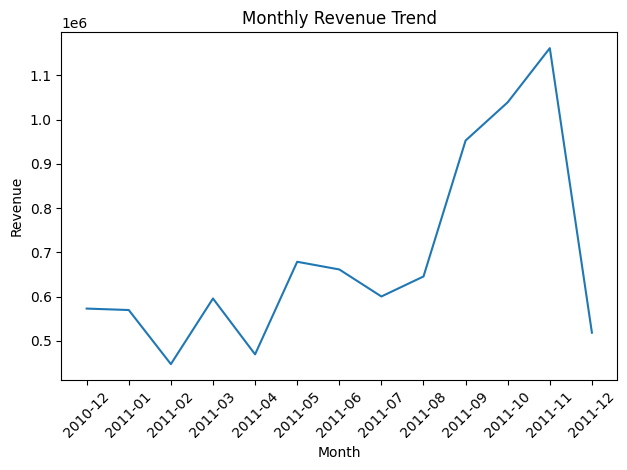

In [17]:
import os
import matplotlib.pyplot as plt

os.makedirs("../images", exist_ok=True)

fig, ax = plt.subplots()
ax.plot(monthly["month"], monthly["monthly_revenue"])
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45)
fig.tight_layout()
fig.savefig("../images/monthly_revenue.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

In [15]:
plt.savefig("../images/monthly_revenue.png", bbox_inches="tight", dpi=200)

<Figure size 640x480 with 0 Axes>

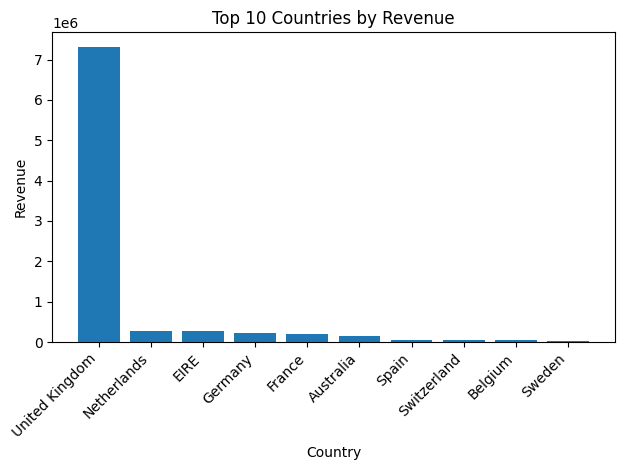

In [18]:
import os
import matplotlib.pyplot as plt

os.makedirs("../images", exist_ok=True)

fig, ax = plt.subplots()
ax.bar(top_countries["Country"], top_countries["total_revenue"])
ax.set_title("Top 10 Countries by Revenue")
ax.set_xlabel("Country")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig("../images/top_countries.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

In [16]:
plt.savefig("../images/top_countries.png", bbox_inches="tight", dpi=200)

<Figure size 640x480 with 0 Axes>

### Key Findings

1. Revenue is highly concentrated in the United Kingdom (~82% of total revenue), indicating strong domestic reliance and limited international diversification.

2. Clear seasonality is observed, with revenue peaking in November 2011 (~£1.16M), consistent with Q4 holiday-driven retail demand.

3. Revenue is heavily concentrated among a small subset of customers, suggesting the presence of high-value wholesale or repeat buyers.

4. Monthly revenue trends show significant growth throughout 2011, indicating business expansion prior to the Q4 peak.

### Business Implications

* The company faces geographic concentration risk.

* Q4 inventory and marketing optimization could significantly impact annual revenue.

* Retention strategies targeting high-value customers could drive substantial ROI.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

customer_rev = pd.read_sql("""
SELECT CustomerID, SUM(Revenue) AS customer_revenue
FROM sales
GROUP BY CustomerID
ORDER BY customer_revenue DESC
""", conn)

customer_rev["cum_revenue"] = customer_rev["customer_revenue"].cumsum()
total = customer_rev["customer_revenue"].sum()
customer_rev["cum_revenue_pct"] = customer_rev["cum_revenue"] / total
customer_rev["customer_rank_pct"] = (customer_rev.index + 1) / len(customer_rev)

customer_rev.head(10)

,CustomerID,customer_revenue,cum_revenue,cum_revenue_pct,customer_rank_pct
0,14646,280206.02,280206.02,0.031444,0.000230
1,18102,259657.30,539863.32,0.060581,0.000461
2,17450,194550.79,734414.11,0.082413,0.000691
3,16446,168472.50,902886.61,0.101318,0.000922
4,14911,143825.06,1046711.67,0.117457,0.001152
5,12415,124914.53,1171626.20,0.131475,0.001383
6,14156,117379.63,1289005.83,0.144647,0.001613
7,17511,91062.38,1380068.21,0.154865,0.001844
8,16029,81024.84,1461093.05,0.163958,0.002074
9,12346,77183.60,1538276.65,0.172619,0.002305


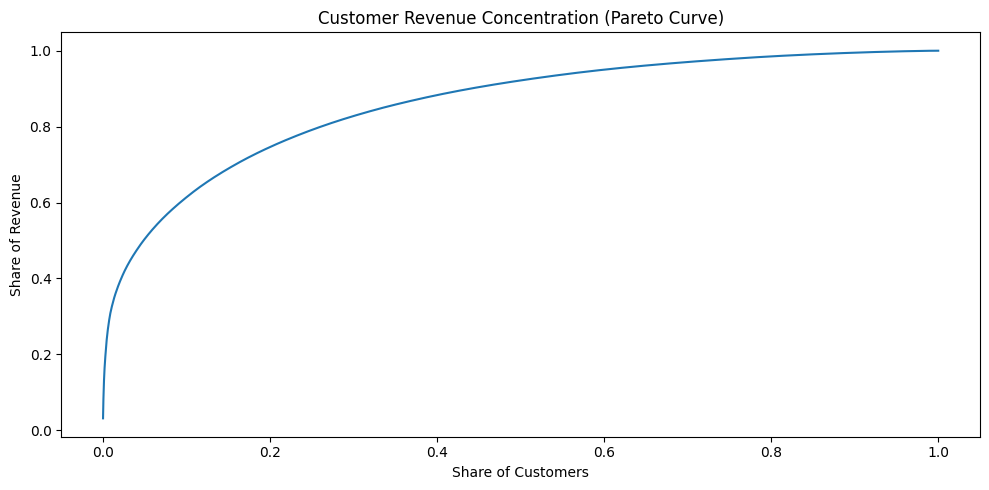

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(customer_rev["customer_rank_pct"], customer_rev["cum_revenue_pct"])
plt.xlabel("Share of Customers")
plt.ylabel("Share of Revenue")
plt.title("Customer Revenue Concentration (Pareto Curve)")
plt.tight_layout()
plt.savefig("../images/pareto_curve.png", dpi=200)
plt.show()

In [14]:
share_20 = customer_rev.loc[customer_rev["customer_rank_pct"] <= 0.20, "customer_revenue"].sum() / total
share_10 = customer_rev.loc[customer_rev["customer_rank_pct"] <= 0.10, "customer_revenue"].sum() / total
share_05 = customer_rev.loc[customer_rev["customer_rank_pct"] <= 0.05, "customer_revenue"].sum() / total

share_05, share_10, share_20

(np.float64(0.5031225344299983),
 np.float64(0.6133411711012168),
 np.float64(0.745940269215624))